# **Deep Thinking RAG Pipeline**

### **Defining State**

In [82]:
from pydantic import BaseModel, Field
from langchain_core.documents import Document
from typing import Literal, List, Optional
from dotenv import load_dotenv
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from rich.pretty import pprint as rprint
from typing import Dict, List, TypedDict
from pprint import pprint as pp
import json
import re

from rich.console import Console # For pretty-printing output with markdown
from rich.markdown import Markdown

# Initialize the rich console for better output formatting
console = Console()

load_dotenv(override=True)

True

In [5]:
# Central Configuration Dictionary to manage all system parameters
config = {
    "data_dir": "../data",                           # Directory to store raw and cleaned data
    "vector_store_dir": "./vector_store",           # Directory to persist our vector store
    "llm_provider": "openai",                       # The LLM provider we are using
    "reasoning_llm": "gpt-4o",                      # The powerful model for planning and synthesis
    "fast_llm": "gpt-4o-mini",                      # A faster, cheaper model for simpler tasks like the baseline RAG
    "embedding_model": "text-embedding-3-small",    # The model for creating document embeddings
    "reranker_model": "cross-encoder/ms-marco-MiniLM-L-6-v2", # The model for precision reranking
    "max_reasoning_iterations": 7,                  # A safeguard to prevent the agent from getting into an infinite loop
    "top_k_retrieval": 10,                          # Number of documents for initial broad recall
    "top_n_rerank": 3,                              # Number of documents to keep after precision reranking
}

In [6]:
# importing required libraries
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
import os

data_path_clean = os.path.join(config["data_dir"], "nvda_10k_2023_clean.txt")

# loadin text data
print('Loading and chunking documents...')
loader = TextLoader(data_path_clean, encoding='utf-8')
docs = loader.load()

# splitting text data into chunks
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=150)
splitted_docs = text_splitter.split_documents(docs)

print(f"Documents loaded and split into {len(splitted_docs)} chunks.")

Loading and chunking documents...
Documents loaded and split into 571 chunks.


In [7]:
# defining state for single step in agent reasoning plan
class Step(BaseModel):
    sub_question: str = Field(description="A spesific answerable question for this step")
    justification: str = Field(description="Simple justification why this step is important for answering query")
    tool: Literal["search_10k", "search_web"] = Field(description="Tool to use for this step")
    keywords: List[str] = Field(description="A list of critical keywords for searching relevant document sections.")
    document_section: Optional[str] = Field(description="A likely document section title (e.g., 'Item 1A. Risk Factors') to search within. Only for 'search_10k' tool.")


# planning model
class Plan(BaseModel):
    steps:List[Step] = Field(description="Detailed multistep plan to answer user's query")


# model for storing past history of completed steps
class PastStep(BaseModel):
    step_index:str = Field(description="Index of each completed step e.g. 1, 2, 3")
    sub_question:str = Field(description="sub question ask in this step")
    retrieved_docs:List[Document] = Field(description="retrieved and ranked docs for this step")
    summary:str = Field(description="Agent's one sentence summary of findings from this step")


In [8]:
# main state dictionary that will pass among all nodes

class RAGState(TypedDict):
    original_question: str
    query_type: str
    plan: Plan
    past_steps: List[PastStep]
    current_step_index: int
    retrieved_docs: List[Document]
    reranked_docs: List[Document]
    synthesized_context: str
    final_answer: str

In [9]:
# defining reasoning model
reasoning_llm = ChatOpenAI(model=config["reasoning_llm"], temperature=0)
fast_llm = ChatOpenAI(model=config["fast_llm"], temperature=0)

### **Building each module of system**

In [10]:
class QueryClassification(BaseModel):
    query_type: Literal["simple", "complex"] = Field(
        description=(
            "'simple' = greetings, personal introductions, casual conversation, "
            "general chitchat that require NO document lookup or web search. "
            "'complex' = any question about companies, finance, earnings, risks, "
            "news, facts, comparisons, or anything that benefits from retrieval."
        )
    )
    reasoning: str = Field(description="One sentence reason for this classification.")


# ── Classifier Chain ───────────────────────────────────────────────────────
classifier_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """You are a query router for a financial research assistant.
Your ONLY job is to classify whether a user query needs document retrieval / web search or not.

Classify as 'simple' ONLY if the query is:
- A greeting (Hi, Hello, Hey)
- Personal introduction (My name is X, I am a student, I work at Y)
- Pure chitchat (How are you, What's up)
- Questions about the assistant itself (Who are you, What can you do)

Classify as 'complex' if the query:
- Asks about any company, person, product, or event
- Requires facts, numbers, dates, or analysis
- Even partially combines chitchat with a real question
  (e.g., "Hi I am X, what are NVIDIA's risks?" → complex)
- Is ambiguous — when in doubt, classify as 'complex'
"""
    ),
    (
        "human",
        "Classify this query: {query}"
    )
])


In [11]:
classifier_chain = (
    classifier_prompt
    | fast_llm.with_structured_output(QueryClassification, method="json_schema")
)

In [12]:
# The system prompt that instructs the LLM how to behave as a planner
planner_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an expert research planner. Your task is to create a clear, multi-step plan to answer a complex user query by retrieving information from multiple sources.
You have two tools available:
1. `search_10k`: Use this to search for information within NVIDIA's 2023 10-K financial filing. This is best for historical facts, financial data, and stated company policies or risks from that specific time period.
2. `search_web`: Use this to search the public internet for recent news, competitor information, or any topic that is not specific to NVIDIA's 2023 10-K.
Decompose the user's query into a series of simple, sequential sub-questions. For each step, decide which tool is more appropriate.
For `search_10k` steps, also identify the most likely section of the 10-K (e.g., 'Item 1A. Risk Factors', 'Item 7. Management's Discussion and Analysis...').
It is critical to use the exact section titles found in a 10-K filing where possible."""),
    ("human", "User Query: {question}") 
])

In [13]:
complex_query_adv = "Based on NVIDIA's 2023 10-K filing, identify their key risks related to competition. Then, find recent news (post-filing, from 2024) about AMD's AI chip strategy and explain how this new strategy directly addresses or exacerbates one of NVIDIA's stated risks."

In [14]:
# creating planner agent
planner_agent = planner_prompt | reasoning_llm.with_structured_output(Plan)

# testing planner agent on complex query
test_result = planner_agent.invoke({"question":complex_query_adv})

rprint(test_result)

c:\Users\masan\OneDrive\Desktop\Adaptive Multi-Agent RAG System\.venv\Lib\site-packages\pydantic\v1\main.py:1054: UserWarning: LangSmith now uses UUID v7 for run and trace identifiers. This warning appears when passing custom IDs. Please use: from langsmith import uuid7
            id = uuid7()
Future versions will require UUID v7.
  input_data = validator(cls_, input_data)


Plan(
│   steps=[
│   │   Step(
│   │   │   sub_question="What are NVIDIA's key risks related to competition as stated in their 2023 10-K filing?",
│   │   │   justification="Understanding NVIDIA's stated risks related to competition will provide a baseline to compare with AMD's recent strategies.",
│   │   │   tool='search_10k',
│   │   │   keywords=['competition', 'risks', 'competitive risks'],
│   │   │   document_section='Item 1A. Risk Factors'
│   │   ),
│   │   Step(
│   │   │   sub_question="What is AMD's AI chip strategy as of 2024?",
│   │   │   justification="Identifying AMD's current AI chip strategy will help in analyzing how it impacts NVIDIA's competitive risks.",
│   │   │   tool='search_web',
│   │   │   keywords=['AMD', 'AI chip strategy', '2024', 'artificial intelligence'],
│   │   │   document_section=None
│   │   ),
│   │   Step(
│   │   │   sub_question="How does AMD's 2024 AI chip strategy address or exacerbate one of NVIDIA's competitive risks?",
│   │   │   justification="This step will directly connect AMD's strategy to NVIDIA's risks, providing a comprehensive understanding of the competitive landscape.",
│   │   │   tool='search_web',
│   │   │   keywords=['AMD', 'NVIDIA', 'competition', 'AI chip', 'strategy impact'],
│   │   │   document_section=None
│   │   )
│   ]
)

In [15]:
# Query rewriter prompt


# The prompt for our query rewriter, instructing it to act as a search expert
query_rewriter_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a search query optimization expert. Your task is to rewrite a given sub-question into a highly effective search query for a vector database or web search engine, using keywords and context from the research plan.
The rewritten query should be specific, use terminology likely to be found in the target source (a financial 10-K or news articles), and be structured to retrieve the most relevant text snippets."""),
    ("human", "Current sub-question: {sub_question}\n\nRelevant keywords from plan: {keywords}\n\nContext from past steps:\n{past_context}")
])

query_rewriter_agent = query_rewriter_prompt | reasoning_llm | StrOutputParser()
print("Query Rewriter Agent created successfully.")

print("\n--- Testing Query Rewriter Agent ---")

test_sub_q = "How does AMD's 2024 AI chip strategy potentially exacerbate the competitive risks identified in NVIDIA's 10-K?"
test_keywords = ['impact', 'threaten', 'competitive pressure', 'market share', 'technological change']

test_past_context = "Step 1 Summary: NVIDIA's 10-K lists intense competition and rapid technological change as key risks. Step 2 Summary: AMD launched its MI300X AI accelerator in 2024 to directly compete with NVIDIA's H100."

# Invoke the agent with our test data
rewritten_q = query_rewriter_agent.invoke({
    "sub_question": test_sub_q,
    "keywords": test_keywords,
    "past_context": test_past_context
})

print(f"Original sub-question: {test_sub_q}")
print(f"Rewritten Search Query: {rewritten_q}")

Query Rewriter Agent created successfully.

--- Testing Query Rewriter Agent ---
Original sub-question: How does AMD's 2024 AI chip strategy potentially exacerbate the competitive risks identified in NVIDIA's 10-K?
Rewritten Search Query: "AMD 2024 AI chip strategy impact on NVIDIA competitive risks 10-K, MI300X vs H100 market share threat, technological change pressure"


In [16]:
# ── Step 1: Load the raw text ──────────────────────────────────────────────
raw_text = docs[0].page_content

# ── Step 2: Skip the Table of Contents ────────────────────────────────────
# The TOC ends near the "WHERE YOU CAN FIND MORE INFORMATION" landmark.
# We slice the text from that point so the TOC "Item X." entries are ignored.
toc_end_marker = "WHERE YOU CAN FIND MORE INFORMATION"
toc_end_pos = raw_text.find(toc_end_marker)
if toc_end_pos == -1:
    raise ValueError("Could not find TOC end marker in document.")
body_text = raw_text[toc_end_pos:]

# ── Step 3: Correct section pattern ───────────────────────────────────────
# In this document, headers appear as:  "ITEM 1. BUSINESS\n"
# i.e., all-caps, on a SINGLE line with the title. Pattern must match this.
# Use a capturing group so re.split returns headers as separate list elements.
section_pattern = r'(ITEM\s+\d+[A-Z]?\.\s+[^\n]+)'

# ── Step 4: Extract titles ─────────────────────────────────────────────────
section_titles = re.findall(section_pattern, body_text)
section_titles = [title.strip().replace('\n', ' ') for title in section_titles]

# ── Step 5: Split into content blocks ─────────────────────────────────────
# re.split with a capturing group returns: [pre, header, content, header, content, ...]
raw_parts = re.split(section_pattern, body_text)

# Even-indexed parts [0, 2, 4, ...] are content; odd-indexed [1, 3, 5, ...] are headers.
# parts[0] is the preamble before first section — skip it.
sections_content = [
    part.strip()
    for part in raw_parts[2::2]   # every content block, skipping preamble
    if part.strip()
]

# ── Step 6: Sanity check ───────────────────────────────────────────────────
print(f"Identified {len(section_titles)} document sections.")
assert len(section_titles) == len(sections_content), \
    f"Mismatch: {len(section_titles)} titles vs {len(sections_content)} content blocks"

Identified 22 document sections.


In [17]:
# creating metadata reach documents

import uuid

# path of data
data_path_clean = os.path.join(config["data_dir"], "nvda_10k_2023_clean.txt")

# text splitter
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=150)

doc_chunks_with_metadata = []

for i, content in enumerate(sections_content):

    title = section_titles[i]
    chunks = text_splitter.split_text(content)

    for chunk in chunks:
        chunk_id = str(uuid.uuid4())
        doc_chunks_with_metadata.append(
            Document(
                page_content=chunk,
                metadata={
                    "section": title,
                    "source_doc": data_path_clean,
                    "id": chunk_id
                }
            )
        )

print(f"Created {len(doc_chunks_with_metadata)} chunks with section metadata.")
print("\n--- Sample Chunk with Metadata ---")

# To prove it worked, let's find a chunk that we know should be in the 'Risk Factors' section and print it
sample_chunk = next(
    c for c in doc_chunks_with_metadata
    if "risk factors" in c.metadata.get("section", "").lower()
)
print(sample_chunk)


Created 541 chunks with section metadata.

--- Sample Chunk with Metadata ---
page_content='In evaluating NVIDIA, the following risk factors should be considered in addition to the other information in this Annual Report on Form 10-K. Purchasing or owning NVIDIA common stock involves investment risks including, but not limited to, the risks described below. Any one of the following risks could harm our business, financial condition, results of operations or reputation, which could cause our stock price to decline, and you may lose all or a part of your investment. Additional risks, trends and uncertainties not presently known to us or that we currently believe are immaterial may also harm our business, financial condition, results of operations or reputation.

 Risk Factors Summary

 Risks Related to Our Industry and Markets

 •Failure to meet the evolving needs of our industry and markets may adversely impact our financial results.

 •

 Failure to meet the evolving needs of our indus

In [18]:
# creating supervisor agent to choose retrieval strategy

class RetrievalDecision(BaseModel):

    strategy: Literal["vector_search", "keyword_search", "hybrid_search"]
    justification: str


retrieval_supervisor_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a retrieval strategy expert. Based on the user's query, you must decide the best retrieval strategy.
You have three options:
1. `vector_search`: Best for conceptual, semantic, or similarity-based queries.
2. `keyword_search`: Best for queries with specific, exact terms, names, or codes (e.g., 'Item 1A', 'Hopper architecture').
3. `hybrid_search`: A good default that combines both, but may be less precise than a targeted strategy."""),
    ("human", "User Query: {sub_question}") # The rewritten search query will be passed here.
])

retrieval_supervisor_agent = retrieval_supervisor_prompt | reasoning_llm.with_structured_output(RetrievalDecision)
print("Retrieval Supervisor Agent created.")

print("\n--- Testing Retrieval Supervisor Agent ---")
query1 = "revenue growth for the Compute & Networking segment in fiscal year 2023"
decision1 = retrieval_supervisor_agent.invoke(query1)
print(f"Query: '{query1}'")
print(f"Decision: {decision1.strategy}, Justification: {decision1.justification}")

query2 = "general sentiment about market competition and technological innovation"
decision2 = retrieval_supervisor_agent.invoke({"sub_question": query2})
print(f"\nQuery: '{query2}'")
print(f"Decision: {decision2.strategy}, Justification: {decision2.justification}")

Retrieval Supervisor Agent created.

--- Testing Retrieval Supervisor Agent ---
Query: 'revenue growth for the Compute & Networking segment in fiscal year 2023'
Decision: keyword_search, Justification: The query is looking for specific financial data related to a particular segment ('Compute & Networking') and a specific time period ('fiscal year 2023'). This requires precise matching of terms and figures, which is best handled by keyword search.

Query: 'general sentiment about market competition and technological innovation'
Decision: vector_search, Justification: The query is conceptual and seeks an understanding of general sentiment, which involves interpreting nuanced opinions and trends. Vector search is best suited for capturing the semantic meaning and context of such queries.


### **Creating Retrieval Strategy**

In [19]:
import numpy as np
from rank_bm25 import BM25Okapi
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings

# embedding function
embedding_function = OpenAIEmbeddings(model=config['embedding_model'])


print("Creating advanced vector store")

advanced_vector_store = Chroma.from_documents(
    documents=doc_chunks_with_metadata,
    embedding=embedding_function
)

print(f"Advanced vector store created with {advanced_vector_store._collection.count()} embeddings.")

Creating advanced vector store
Advanced vector store created with 541 embeddings.


In [20]:
print("Bulding BM25 Index keyword search")

tokenized_corpus = [doc.page_content.split(" ") for doc in doc_chunks_with_metadata]

doc_ids = [doc.metadata["id"] for doc in doc_chunks_with_metadata]

doc_map = {doc.metadata["id"]:doc for doc in doc_chunks_with_metadata}

bm25 = BM25Okapi(tokenized_corpus)


Bulding BM25 Index keyword search


In [21]:
# defining retrieval tools

# vector search only
def vector_search(query:str, section_filter:str=None, k:int=10):
    filter_dict = {'section': section_filter} if section_filter and "Unknown" not in section_filter else None
    return advanced_vector_store.similarity_search(query=query, filter=filter_dict, k=k)

# keyword search only
def bm25_search(query:str, k:int=10):
    tokenized_query = query.split(" ")
    scores = bm25.get_scores(tokenized_query)

    sorted_scores = np.argsort(scores)[::-1][:k]

    return [doc_map[doc_ids[id]] for id in sorted_scores]

# hybrid search
def hybrid_search(query:str, section_filter:str=None, k:int=10):

    semantic_doc = vector_search(query, section_filter, k)
    bm25_docs = bm25_search(query, k)

    all_docs  = {docs.metadata["id"]:docs for docs in semantic_doc+bm25_docs}.values()

    ranked_list = [[doc.metadata["id"] for doc in semantic_doc], [doc.metadata["id"] for doc in bm25_docs]]

    rff_scores = {}
    
    for doc_list in ranked_list:
        for i, doc in enumerate(doc_list):
            if doc not in rff_scores:
                rff_scores[doc] = 0

            rff_scores[doc] += 1/(i+61)
    
    sorted_doc_ids = sorted(rff_scores.keys(), key=lambda x:rff_scores[x], reverse=True)
    final_doc = [doc_map[doc_id] for doc_id in sorted_doc_ids[:k]]

    return final_doc


In [22]:
# implementing cross encoder

from sentence_transformers import CrossEncoder

# initializing cross encoder reranker
reranker = CrossEncoder(config["reranker_model"])

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 2757.94it/s]


In [23]:
def rerank_documents_function(query:str, documents:List[Document])->List[Document]:

    if not documents:
        return []

    pairs = [(query, doc.page_content) for doc in documents]
    scores = reranker.predict(pairs)

    doc_scores = list(zip(documents, scores))
    doc_scores.sort(key=lambda x:x[1], reverse=True)

    rerank_docs = [doc for doc, scores in doc_scores[:config["top_n_rerank"]]]

    return rerank_docs

In [24]:
# The prompt for our distiller agent, instructing it to synthesize and be concise
distiller_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a helpful assistant. Your task is to synthesize the following retrieved document snippets into a single, concise paragraph.
The goal is to provide a clear and coherent context that directly answers the question: '{question}'.
Focus on removing redundant information and organizing the content logically. Answer only with the synthesized context."""),
    ("human", "Retrieved Documents:\n{context}") 
])

In [25]:
# creating distiller agent

distiller_agent = distiller_prompt|reasoning_llm|StrOutputParser()


In [26]:
# web search tool
from langchain_community.tools.tavily_search import TavilySearchResults

web_search_tool = TavilySearchResults(k=3)

C:\Users\masan\AppData\Local\Temp\ipykernel_23736\3968851161.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(k=3)


In [27]:
def web_search_function(query:str)->List[Document]:

    web_results = web_search_tool.invoke({"query":query})
    # returning web results in form of list of document objects as our downstrim process are compatible with Document objects
    return [
        Document(
        page_content=res["content"],
        metadata={"source":res["url"]}
    ) for res in web_results
    ]

In [28]:
# Test the web search function with a query about AMD's 2024 strategy
print("\n--- Testing Web Search Tool ---")
test_query_web = "AMD AI chip strategy 2024"
test_results_web = web_search_function(test_query_web)
print(f"Found {len(test_results_web)} results for query: '{test_query_web}'")
# Print a snippet from the first result to see what we got back
if test_results_web:
    print(f"Top result snippet: {test_results_web[0].page_content[:250]}...")


--- Testing Web Search Tool ---
Found 5 results for query: 'AMD AI chip strategy 2024'
Top result snippet: Production Capacity Expansion

To meet the growing demand for AI chips, AMD has been actively working on expanding its production capacity. The company aims to increase its market share in the AI chip market, which is projected to reach USD 45 billio...


In [29]:
# The prompt for our reflection agent, instructing it to be concise and factual
reflection_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a research assistant. Based on the retrieved context for the current sub-question, write a concise, one-sentence summary of the key findings.
This summary will be added to our research history. Be factual and to the point."""),
    ("human", "Current sub-question: {sub_question}\n\nDistilled context:\n{context}")
])

In [30]:
# Create the agent by piping our prompt to the reasoning LLM and a string output parser
reflection_agent = reflection_prompt | reasoning_llm | StrOutputParser()
print("Reflection Agent created.")

Reflection Agent created.


In [31]:
class Decision(BaseModel):
    next_action: Literal["CONTINUE_PLAN", "FINISH"]
    justification: str

In [32]:
# The prompt for our policy agent, instructing it to act as a master strategist
policy_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a master strategist. Your role is to analyze the research progress and decide the next action.
You have the original question, the initial plan, and a log of completed steps with their summaries.
- If the collected information in the Research History is sufficient to comprehensively answer the Original Question, decide to FINISH.
- Otherwise, if the plan is not yet complete, decide to CONTINUE_PLAN."""),
    ("human", "Original Question: {question}\n\nInitial Plan:\n{plan}\n\nResearch History (Completed Steps):\n{history}")
])

In [33]:
# Create the agent by piping our prompt to the reasoning LLM and structuring its output with our Decision class
policy_agent = policy_prompt | reasoning_llm.with_structured_output(Decision)
print("Policy Agent created.")


Policy Agent created.


## **Building Graph**

In [34]:
# A helper function to format the research history for prompts 
def get_past_context(past_steps:List[PastStep])->str:
    return "\\n\\n".join([f"Step {s['step_index']}: {s['sub_question']}\\nSummary: {s['summary']}" for s in past_steps])

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [62]:
# query classifier node
def classify_query_node(state: RAGState) -> dict:
    result: QueryClassification = classifier_chain.invoke(
        {"query": state["original_question"]}
    )
    print(f"  [Classifier] Type: {result.query_type} | Reason: {result.reasoning}")
    return {"query_type": result.query_type, "past_steps": []}

In [ ]:
# planner node
def planner_node(state: RAGState)-> Dict:
    
    # print("--- 🧠: Generating Plan ---")
    # plan = planner_agent.invoke({"question": state["original_question"]})
    # rprint(plan)

    # return {"plan": plan, "current_step_index": 0, "past_steps": []}

    existing_plan = state.get("plan")         # Returns None if key missing
    if existing_plan is not None and existing_plan.steps:
        # Plan already exists — just advance the index
        return {}

    # First time — create the plan
    print("--- 🧠: Generating Plan ---")
    new_plan = planner_agent.invoke(state["original_question"])
    rprint(new_plan)
    return {
        "plan": new_plan,
        "current_step_index": 0,
        "past_steps": []
    }
    
  

In [37]:
# Retrieval Node from the 10-K document
def retrieval_node(state: RAGState) -> Dict:
    
    current_step_index = state["current_step_index"]
    current_step = state["plan"].steps[current_step_index]
    print(f"--- 🔍: Retrieving from 10-K (Step {current_step_index + 1}: {current_step.sub_question}) ---")
    
    past_context = get_past_context(state['past_steps'])
    rewritten_query = query_rewriter_agent.invoke({
        "sub_question": current_step.sub_question,
        "keywords": current_step.keywords,
        "past_context": past_context
    })
    print(f"  Rewritten Query: {rewritten_query}")
    
    # Get the supervisor's decision on which retrieval strategy is best.
    retrieval_decision = retrieval_supervisor_agent.invoke({"sub_question": rewritten_query})
    print(f"  Supervisor Decision: Use `{retrieval_decision.strategy}`. Justification: {retrieval_decision.justification}")

    # Based on the decision, execute the correct retrieval function.
    if retrieval_decision.strategy == 'vector_search':
        retrieved_docs = vector_search(rewritten_query, section_filter=current_step.document_section, k=config['top_k_retrieval'])
    elif retrieval_decision.strategy == 'keyword_search':
        retrieved_docs = bm25_search(rewritten_query, k=config['top_k_retrieval'])
    else: 
        retrieved_docs = hybrid_search(rewritten_query, section_filter=current_step.document_section, k=config['top_k_retrieval'])
    
    # Return the retrieved documents to be added to the state.
    return {"retrieved_docs": retrieved_docs}

In [38]:
# Node 2b: Retrieval from the Web
def web_search_node(state: RAGState) -> Dict:
    # Get the details for the current step.
    current_step_index = state["current_step_index"]
    current_step = state["plan"].steps[current_step_index]
    print(f"--- 🌐: Searching Web (Step {current_step_index + 1}: {current_step.sub_question}) ---")
    
    # Rewrite the sub-question for a web search engine.
    past_context = get_past_context(state['past_steps'])
    rewritten_query = query_rewriter_agent.invoke({
        "sub_question": current_step.sub_question,
        "keywords": current_step.keywords,
        "past_context": past_context
    })
    print(f"  Rewritten Query: {rewritten_query}")
    retrieved_docs = web_search_function(rewritten_query)
    return {"retrieved_docs": retrieved_docs}

In [39]:
# Node 3: The Reranker
def rerank_node(state: RAGState) -> Dict:
    print("--- 🎯: Reranking Documents ---")
    # Get the current step's details.
    current_step_index = state["current_step_index"]
    current_step = state["plan"].steps[current_step_index]
    # Call our reranking function on the documents we just retrieved.
    reranked_docs = rerank_documents_function(current_step.sub_question, state["retrieved_docs"])
    print(f"  Reranked to top {len(reranked_docs)} documents.")
    # print(reranked_docs)
    return {"reranked_docs": reranked_docs}

In [40]:
# Node 4: The Compressor / Distiller
def compression_node(state: RAGState) -> Dict:
    print("--- ✂️: Distilling Context ---")
    current_step_index = state["current_step_index"]
    current_step = state["plan"].steps[current_step_index]
    context = format_docs(state["reranked_docs"])
    # Call our distiller agent to synthesize them into one paragraph.
    synthesized_context = distiller_agent.invoke({"question": current_step.sub_question, "context": context})
    print(f"  Distilled Context Snippet: {synthesized_context[:200]}...")
    return {"synthesized_context": synthesized_context}

In [41]:
# Node 5: The Reflection / Update Step
def reflection_node(state: RAGState) -> Dict:
    print("--- : Reflecting on Findings ---")
    current_step_index = state["current_step_index"]
    current_step = state["plan"].steps[current_step_index]
    summary = reflection_agent.invoke({"sub_question": current_step.sub_question, "context": state['synthesized_context']})
    print(f"  Summary: {summary}")
    
    # Create a new PastStep dictionary with all the results from this step.
    new_past_step = {
        "step_index": current_step_index + 1,
        "sub_question": current_step.sub_question,
        "retrieved_docs": state['reranked_docs'], 
        "summary": summary
    }
    
    # Append the new step to our history and increment the step index to move to the next step.
    return {"past_steps": state["past_steps"] + [new_past_step], "current_step_index": current_step_index + 1}

In [68]:
# Node 6: The Final Answer Generator
def final_answer_node(state: RAGState) -> Dict:
    print("--- ✅: Generating Final Answer with Citations ---")
    # First, we need to gather all the evidence we've collected from ALL past steps.
    final_context = ""
    for i, step in enumerate(state['past_steps']):
        final_context += f"\\n--- Findings from Research Step {i+1} ---\\n"
        # We include the source metadata (section or URL) for each document to enable citations.
        for doc in step['retrieved_docs']:
            source = doc.metadata.get('section') or doc.metadata.get('source')
            final_context += f"Source: {source}\\nContent: {doc.page_content}\\n\\n"
    
    # We create a new prompt specifically for generating the final, citable answer.
    final_answer_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """You are a domain-restricted RAG assistant.

You are allowed to answer ONLY based on:
1. The provided research history and context
2. The available source corpus for this system, which is limited to the NVIDIA 10-K / annual report content supplied to the system

Your behavior rules:

A. Scope
- You are NOT a general-purpose assistant.
- You are NOT a general financial advisor.
- You must NOT answer using outside world knowledge.
- If the user's question is outside the NVIDIA 10-K source/corpus and provided context, say so clearly.

B. Query handling
1. If the user asks a greeting, introduction, or capability question such as:
   - "Hi"
   - "My name is Yash"
   - "How can you help me?"
   - "Who are you?"
   then respond briefly and naturally.
   Explain that you can help only with questions related to the NVIDIA 10-K source available in this system.
   Give a few examples, such as risks, business segments, competition, revenue-related disclosures, or other details present in the filing.

2. If the user asks a question that requires retrieval/analysis and the provided context contains enough information:
   - Answer using only the provided context.
   - Synthesize across multiple retrieved findings if needed.
   - Do not add facts that are not supported by the context.
   - At the end of each sentence that relies on specific information, add a citation.
   - For 10-K material, use: [Source: <section title>]
   - For web results, use: [Source: <URL>]

3. If the question is related to the NVIDIA 10-K domain but the provided context does not contain enough information:
   - Say that the answer could not be found in the available context/source.
   - Do not guess or fill in from general knowledge.

4. If the question is clearly out of scope, such as:
   - general programming help
   - celebrity facts
   - unrelated current events
   - topics unrelated to the NVIDIA 10-K source
   then politely refuse.
   State that this assistant can only help with questions grounded in the NVIDIA 10-K source available in this system.

C. Style
- Be clear, concise, and factual.
- Do not mention internal chain-of-thought or hidden reasoning.
- For simple greetings/capability questions, keep the answer short.
- For retrieval-based questions, provide a structured, multi-paragraph answer when useful.
- Never fabricate citations.
"""
    ),
    (
        "human",
        """Original Question: {question}

Research History and Context:
{context}"""
    )
])
    
    # We create a temporary agent for this final task and invoke it.
    final_answer_agent = final_answer_prompt | reasoning_llm | StrOutputParser()
    final_answer = final_answer_agent.invoke({"question": state['original_question'], "context": final_context})
    # Update the state with the final answer.
    return {"final_answer": final_answer}

In [53]:
# Conditional Edge 1: The Tool Router
def route_by_tool(state: RAGState) -> str:
    # Get the index of the current step we are on.
    current_step_index = state["current_step_index"]
    # Get the full details of the current step from the plan.
    current_step = state["plan"].steps[current_step_index]
    # Return the name of the tool specified for this step.
    # LangGraph will use this string to decide which node to go to next.
    return current_step.tool

def route_by_classifier(state: RAGState)->str:
    return state['query_type']


In [54]:
# Conditional Edge 2: The Main Control Loop
def should_continue_node(state: RAGState) -> str:
    print("--- 🚦: Evaluating Policy ---")
    # Get the index of the step we are about to start.
    current_step_index = state["current_step_index"]
    
    # Condition 1: Have we completed all the steps in the plan?
    if current_step_index >= len(state["plan"].steps):
        print("  -> Plan complete. Finishing.")
        return "finish"
    
    # Condition 2: Have we exceeded our safety limit for the number of iterations?
    if current_step_index >= config["max_reasoning_iterations"]:
        print("  -> Max iterations reached. Finishing.")
        return "finish"

    if state.get("reranked_docs") is not None and not state["reranked_docs"]:
        print("  -> Retrieval failed for the last step. Continuing with next step in plan.")
        return "continue"

    # If none of the basic conditions are met, it's time to ask our Policy Agent.
    # We format the history and plan into strings for the prompt.
    history = get_past_context(state['past_steps'])
    plan_str = json.dumps([s.model_dump() for s in state['plan'].steps])

    # Invoke the policy agent to get its strategic decision.
    decision = policy_agent.invoke({"question": state["original_question"], "plan": plan_str, "history": history})
    print(f"  -> Decision: {decision.next_action} | Justification: {decision.justification}")
    
    # Based on the agent's decision, return the appropriate signal.
    if decision.next_action == "FINISH":
        return "finish"
    else: 
        return "continue"

In [69]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(RAGState)

# Add all of our Python functions as nodes in the graph
graph.add_node("query_classifier", classify_query_node) # classify if query is complex or directly answered by llm with its parametric knowledge
graph.add_node("plan", planner_node)                     # The node that creates the initial plan
graph.add_node("retrieve_10k", retrieval_node)        # The node for internal document retrieval
graph.add_node("retrieve_web", web_search_node)       # The node for external web search
graph.add_node("rerank", rerank_node)                 # The node that performs precision reranking
graph.add_node("compress", compression_node)          # The node that distills the context
graph.add_node("reflect", reflection_node)            # The node that summarizes findings and updates history
graph.add_node("generate_final_answer", final_answer_node) # The node that synthesizes the final answer

In [70]:
# The entry point of our graph is the "plan" node. Every run starts here.
graph.set_entry_point("query_classifier")
graph.add_conditional_edges("query_classifier", 
               route_by_classifier,
               {
                   "simple":"generate_final_answer",
                   "complex":"plan"
               },
                   )

# After the "plan" node, we use our first conditional edge to decide which tool to use.
graph.add_conditional_edges(
    "plan",           # The source node
    route_by_tool,    # The function that makes the decision
    {                 # A dictionary mapping the function's output string to the destination node
        "search_10k": "retrieve_10k",
        "search_web": "retrieve_web",
    },
)

# After retrieving from either the 10-K or the web, the flow is linear for a bit.
graph.add_edge("retrieve_10k", "rerank") # After internal retrieval, always go to rerank.
graph.add_edge("retrieve_web", "rerank") # After web retrieval, also always go to rerank.
graph.add_edge("rerank", "compress")      # After reranking, always go to compress.
graph.add_edge("compress", "reflect")     # After compressing, always go to reflect.

# After the "reflect" node, we hit our main conditional edge, which controls the reasoning loop.
graph.add_conditional_edges(
    "reflect",        # The source node
    should_continue_node, # The function that calls our Policy Agent
    {                 # A dictionary mapping the decision to the next step
        "continue": "plan", # If the decision is "continue", we loop back to the "plan" node to route the next step.
        "finish": "generate_final_answer", # If the decision is "finish", we proceed to generate the final answer.
    },
)

# The "generate_final_answer" node is the last step before the end.
graph.add_edge("generate_final_answer", END) # After generating the answer, the graph concludes.
print("StateGraph constructed successfully.")


StateGraph constructed successfully.


Graph compiled successfully.


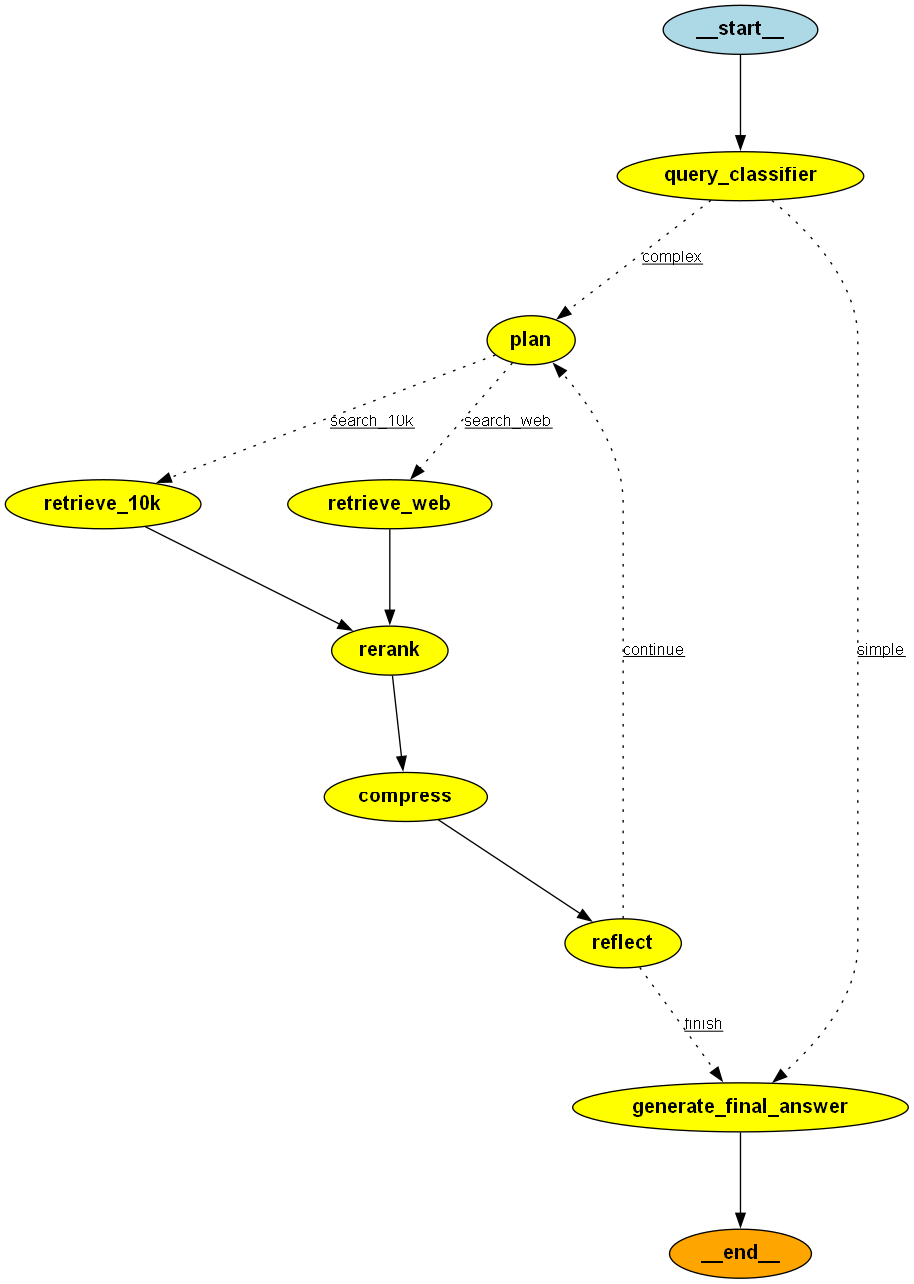

In [71]:
# The .compile() method takes our graph definition and creates a runnable object.
deep_thinking_rag_graph = graph.compile()
print("Graph compiled successfully.")


# Now, let's visualize the architecture we've built.
try:
    from IPython.display import Image, display
    # We can get a PNG image of the graph's structure.
    png_image = deep_thinking_rag_graph.get_graph().draw_png()
    # Display the image in our notebook.
    display(Image(png_image))
except Exception as e:
    # This can fail if pygraphviz and its system dependencies are not installed.
    print(f"Graph visualization failed: {e}. Please ensure pygraphviz is installed.")


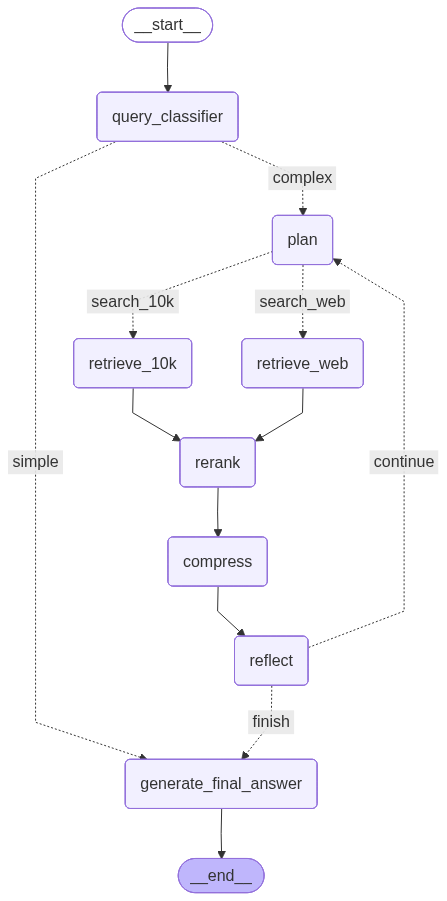

In [60]:
deep_thinking_rag_graph

In [79]:
# This will hold the final state of the graph after the run is complete.
final_state = None
# The initial input for our graph, containing the original user query.
graph_input = {"original_question": complex_query_adv}

print("--- Invoking Deep Thinking RAG Graph ---")
# We use .stream() to watch the agent's process in real-time.
# "values" mode means we get the full RAGState object after each step.
for chunk in deep_thinking_rag_graph.stream(graph_input, stream_mode="values"):
    # The final chunk in the stream will be the terminal state of the graph.
    final_state = chunk
print("\n--- Graph Stream Finished ---")

--- Invoking Deep Thinking RAG Graph ---
  [Classifier] Type: complex | Reason: The query asks for specific information about NVIDIA's 10-K filing and recent news about AMD's AI chip strategy, which requires document retrieval and analysis.
--- 🔍: Retrieving from 10-K (Step 1: What are NVIDIA's key risks related to competition as stated in their 2023 10-K filing?) ---
  Rewritten Query: "NVIDIA 2023 10-K competition risks competitive landscape market competition"
  Supervisor Decision: Use `keyword_search`. Justification: The query contains specific terms such as 'NVIDIA', '2023 10-K', and 'competition risks', which are likely to be found in exact form within financial documents or reports. Keyword search is best suited for retrieving documents that contain these exact terms, especially when dealing with formal documents like a 10-K report.
--- 🎯: Reranking Documents ---
  Reranked to top 3 documents.
--- ✂️: Distilling Context ---
  Distilled Context Snippet: NVIDIA's key risks relate

In [83]:
console.print(Markdown(final_state["final_answer"]))

Based on NVIDIA's 2023 10-K filing, one of the key risks related to competition is the potential for competitors to
offer products, services, and technologies that are cheaper or provide better functionality or features than       
NVIDIA's offerings. This could result in lower than expected selling prices for NVIDIA's products. Additionally,   
some competitors have advantages such as operating their own fabrication facilities, having longer operating       
histories, larger customer bases, more comprehensive IP portfolios, and greater financial, sales, marketing, and   
distribution resources. These factors could enable competitors to acquire market share more effectively and        
capitalize on new market opportunities more quickly than NVIDIA [Source: ITEM 1A. RISK FACTORS].                   

Recent news about AMD's AI chip strategy indicates that AMD is making significant strides to challenge NVIDIA's    
dominance in the AI chip market. AMD has projected $4.5 billion in AI chip sales for 2024, following the launch of 
its MI300X chips. AMD's strategy focuses on providing raw computational horsepower at competitive prices, which    
positions it as a viable alternative for customers prioritizing performance and value over a comprehensive software
ecosystem [Source:                                                                                                 
https://www.reuters.com/technology/artificial-intelligence/openai-builds-first-chip-with-broadcom-tsmc-scales-back-
foundry-ambition-2024-10-29;                                                                                       
https://www.marketsandmarkets.com/blog/SE/amd-ai-chip-strategy-gaining-ground-in-a-competitive-market].            

This strategy directly addresses NVIDIA's stated risk of competitors offering cheaper or better-functioning        
products. By focusing on performance and competitive pricing, AMD is appealing to customers who are looking for    
alternatives to NVIDIA, potentially intensifying competition and impacting NVIDIA's market share and pricing       
strategies.